In [2]:
import subprocess
import sys

for n in range(1, 9):
    cp = subprocess.run(
        f"conda run -n ba_testing mpirun -n {n} python -u  mpiStabilityTest2.py",
        shell=True,
        text=True,
        # Send stderr to stdout and don't automatically throw an exception in order
        # to replicate checking the output of a shell command.
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print("The output is")
    print(cp.stdout)
    if cp.returncode != 0:
        print(f"Error! {cp.returncode}")
        # Maybe exit if you shouldn't continue on failure
        sys.exit(cp.returncode)



The output is
Starting calculation
Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10
Calculation completed in 31.57123673599998 seconds (± 0.24457148533508333)
31.57123673599998
The output is
Starting calculation
Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10
Calculation completed in 19.36674668390001 seconds (± 0.031643954032843515)
19.36674668390001
The output is
Starting calculation
Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10
Calculation completed in 13.527456195499985 seconds (± 0.033594718460007895)
13.527456195499985
The output is
Starting calculation
Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10
Calculation completed in 11.181665653099992 seconds (± 0.028260808942168036)
11.181665653099992
The output is
Starting calculation
Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
R

In [8]:
import subprocess
import sys

for n in range(8, 9):
    cp = subprocess.run(
        f"conda run -n ba_testing mpirun -n 20 python -u  mpiStabilityTest2.py",
        shell=True,
        text=True,
        # Send stderr to stdout and don't automatically throw an exception in order
        # to replicate checking the output of a shell command.
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print("The output is")
    print(cp.stdout)
    if cp.returncode != 0:
        print(f"Error! {cp.returncode}")
        # Maybe exit if you shouldn't continue on failure
        sys.exit(cp.returncode)

The output is
Starting calculation
Run 1/10
Calculation completed in 6.725131893000253 seconds (± 0.0)
6.725131893000253


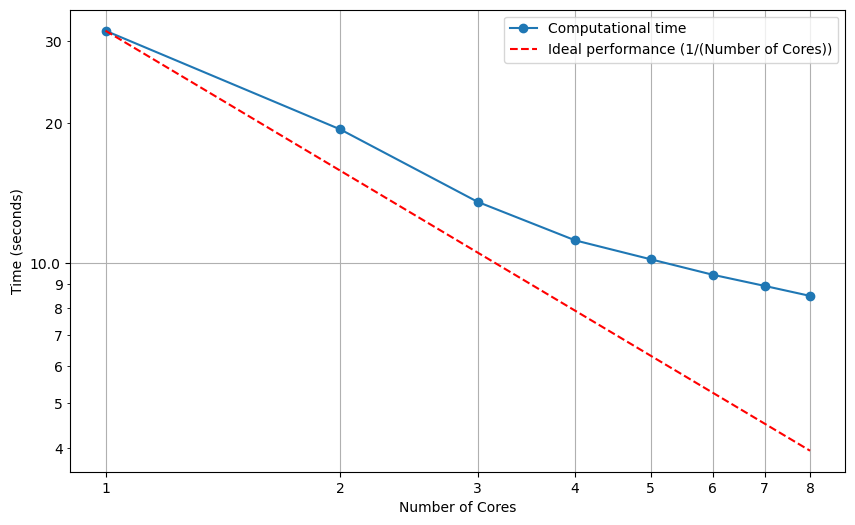

In [69]:
import numpy as np
number_of_cores = np.array([1, 2, 3, 4, 5, 6, 7, 8])

times = np.array([31.57123673599998, 19.36674668390001, 13.527456195499985,  11.181665653099992, 10.180570026500003, 9.433349273200042, 8.923243415999991, 8.493755990800036])
#times = 1/times
# Plotting the results
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
fig, (ax) = plt.subplots(1, 1, figsize=(10, 6))

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax.plot(number_of_cores, times, marker='o', label='Computational time')
ax.plot(number_of_cores, times[0]/number_of_cores, linestyle='--', color='red', label='Ideal performance (1/(Number of Cores))')
ax.set_xlabel('Number of Cores')
ax.set_ylabel('Time (seconds)')
ax.set_xticks(number_of_cores)
ax.legend()
ax.grid()

import tikzplotlib
tikzplotlib.save("mpiStabilityTest2_performance.tex")